In [5]:
# Imports
from dataclasses import dataclass
import random
import numpy as np
import csv
from deap.tools import cxOnePoint, cxTwoPoints
import time
import copy
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from deap import base, creator, tools, algorithms

random.seed(42)

In [6]:
# A gene contains 2 attributes : the food item's name and the number of servings of this item
@dataclass
class Gene:
    food_item_name: str
    serving: int

In [7]:
# We make a list representing all the meals we have in 1 chromosome
Meals = ["Breakfast", "Snack 1", "Lunch", "Snack 2", "Dinner"]
# We make a list representing all the food groups we have in 1 meal
Food_Groups = ["Vegetables", "Fruits", "Grains", "Protein", "Dairy", "Fats and Oils"]

In [8]:
# Load dataset
def load_food_data(csv_path):
    food_data = {}
    meal_flags = {}

    with open(csv_path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)

        for row in reader:
            group = row['Category']
            food = row['Food Item']

            if group not in food_data:
                food_data[group] = {}

            # Safely convert numeric columns, use 0 if empty
            def safe_float(x):
                try:
                    return float(x)
                except (ValueError, TypeError):
                    return 0.0

            food_data[group][food] = {
                'p': safe_float(row['Protein (g)']),
                'f': safe_float(row['Fats (g)']),
                'c': safe_float(row['Carbohydrates (g)']),
                'cal': safe_float(row['Calories (kcal)']),
                'pref': safe_float(row['User Preference'])
            }

            # Safely convert meal flags (0 if empty)
            def safe_int(x):
                try:
                    return int(x)
                except (ValueError, TypeError):
                    return 0

            meal_flags[food] = {
                'Breakfast': safe_int(row['Breakfast']),
                'Snack 1': safe_int(row['Snack 1']),
                'Lunch': safe_int(row['Lunch']),
                'Snack 2': safe_int(row['Snack 2']),
                'Dinner': safe_int(row['Dinner'])
            }

    return food_data, meal_flags


FOOD_DATA, MEAL_FLAGS = load_food_data("Processed_Bahrain_Food_Dataset.csv")

In [9]:
# Dictionary that contains all the saudi guideline's servings
SERVING_GUIDELINES_BY_KCAL = {
    1200: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 0},
        "Snack 2": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 0}
    },

    1300: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 0}
    },

    1400: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 1, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 0}
    },

    1500: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    1600: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    1700: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    1800: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 1}
    },

    1900: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 1}
    },

    2000: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 2, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 2, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    2200: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 2, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 2, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 1}
    }
}

In [10]:
# DEAP Configuration
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()


# Initialize Population
def create_individual():
    # Initializes 30 genes following 1600 kcal
    genes = []
    for meal in Meals:
        for group in Food_Groups:
            # Get the fixed serving count for this meal/group
            serving_count = SERVING_GUIDELINES_BY_KCAL[TARGET_KCAL][meal][group]

            # Filter foods allowed for this meal
            allowed_foods = [
                food for food in FOOD_DATA[group].keys() if MEAL_FLAGS[food][meal] == 1
            ]
            if not allowed_foods:
                allowed_foods = list(FOOD_DATA[group].keys())  # fallback

            # Randomly select food from allowed foods
            food_name = random.choice(allowed_foods)

            # Create gene with guideline serving count
            genes.append(Gene(food_item_name=food_name, serving=serving_count))

    return creator.Individual(genes)


toolbox.register("individual", create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


# Fitness Function
def evaluate_meal_plan(individual):
    total_p = 0.0  # Protein grams
    total_f = 0.0  # Fat grams
    total_c = 0.0  # Carbohydrates grams
    total_cal = 0.0  # Total Calories
    total_pref = 0.0  # Total user preference

    # Sum up all grams and calories based on food item and serving count
    for gene in individual:
        group_name = None
        # Find which group this food belongs to
        for group, foods in FOOD_DATA.items():
            if gene.food_item_name in foods:
                group_name = group
                break

        if group_name:
            stats = FOOD_DATA[group_name][gene.food_item_name]
            total_p += stats['p'] * gene.serving
            total_f += stats['f'] * gene.serving
            total_c += stats['c'] * gene.serving
            total_cal += stats['cal'] * gene.serving
            if gene.serving > 0:
                total_pref += stats['pref']
    # Calculate actual macro percentages (p_c, p_p, p_f)
    g_total = total_p + total_f + total_c
    if g_total == 0: return 0,  # Avoid division by zero

    p_p = total_p / g_total
    p_f = total_f / g_total
    p_c = total_c / g_total

    # Target Ratios (The AMDR values)
    r_p, r_f, r_c = 0.20, 0.25, 0.55

    # Objective function: J_macro (Squared Error)
    j_macro = (p_c - r_c) ** 2 + (p_p - r_p) ** 2 + (p_f - r_f) ** 2

    # Total calorie constraint (J_cal)
    r = (total_cal - TARGET_KCAL) / TARGET_KCAL
    j_cal = min(1, r ** 2)

    # Variety constraint (J_var)
    N = sum(1 for gene in individual if
            gene.serving > 0)  # total number of food items in the chromosome (N is taken from the report)
    # count food appearance
    food_appearance = {}
    for gene in individual:
        if gene.serving > 0:
            food_appearance[gene.food_item_name] = food_appearance.get(gene.food_item_name, 0) + 1
    # Calculate the penalty for variety
    j_var = 0
    for food_name, count in food_appearance.items():
        # we penalize if the food item appears more than once
        if count > 1:
            j_var += max(0, count - 1) ** 2
    # Normalize the penalty
    j_var = j_var / ((N - 1) ** 2)

    # User preference constraint (J_pref)
    j_pref = total_pref / N

    # Calculate the score
    w_macro, w_cal, w_var, w_pref = 0.25, 0.25, 0.25, 0.25
    score = w_macro * j_macro + w_var * j_var + w_cal * j_cal + w_pref * j_pref

    # store the penalties to print later
    individual.j_var = j_var
    individual.j_macro = j_macro
    individual.j_cal = j_cal
    individual.j_pref = j_pref

    # We want to minimize score, so we return a fitness that increases as score decreases
    return 1 / (1 + score),


# Crossover
def one_cx_meal_plan(parent1, parent2):
    GROUPS = 6
    MEALS = 5

    m1 = random.randrange(1, MEALS)
    cut = m1 * GROUPS
    parent1[cut:], parent2[cut:] = parent2[cut:], parent1[cut:]
    return parent1, parent2


def two_cx_meal_plan(parent1, parent2):
    GROUPS = 6
    MEALS = 5

    # Choose 2 meal cut points
    m1, m2 = sorted(random.sample(range(1, MEALS), 2))
    cut1, cut2 = m1 * GROUPS, m2 * GROUPS

    # Swap full meals
    parent1[cut1:cut2], parent2[cut1:cut2] = parent2[cut1:cut2], parent1[cut1:cut2]

    return parent1, parent2


# Mutation
def mutate_meal_plan(individual):
    mutations_done = 0
    all_indices = list(range(len(individual)))  # List of all possible indices in the chromosome
    random.shuffle(all_indices)  # Shuffle to pick randomly without repeating the same one

    for i in all_indices:
        if mutations_done >= 2:
            break  # Stop once we have mutated 2 genes

        # Check if the serving size is not zero
        if individual[i].serving > 0:
            # Find which group it belongs to (Vegetables, Grains, ...)
            group_name = Food_Groups[i % 6]
            # What meal it belongs to (Breakfast, Snack 1,...)
            meal = Meals[i // 6]

            # Check compatibility
            allowed_foods = [
                food for food in FOOD_DATA[group_name].keys() if MEAL_FLAGS[food][meal] == 1
            ]
            if allowed_foods:
                # Pick a new food name from food group dictionary, but the serving remains the same
                individual[i].food_item_name = random.choice(allowed_foods)
                mutations_done += 1
    return individual,


toolbox.register("evaluate", evaluate_meal_plan)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", cxOnePoint)  # one-point crossover
toolbox.register("mutate", mutate_meal_plan)

In [11]:
# GA Execution Loop
def run_simulation(target_kcal, pop_size, cxpb, mutpb, patience):
    global TARGET_KCAL
    TARGET_KCAL = target_kcal  # tells create_individual which guideline to use

    pop = toolbox.population(n=pop_size)

    hof = tools.HallOfFame(1)  # keeps the absolute best found across all generations

    mu = len(pop)  # number of individuals to select for the next generation
    lambd = 100  # number of children to produce in each generation

    MAX_GEN = 300  # max num no more
    PATIENCE = patience
    EPS = 1e-6  # small new update ignor

    best_so_far = None
    stagnant = 0

    # Statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)

    for gen in range(MAX_GEN):

        # run ONE generation
        algorithms.eaMuPlusLambda(
            pop, toolbox,
            mu=mu,
            lambda_=lambd,
            cxpb=cxpb,
            mutpb=mutpb,
            ngen=1,
            stats=stats,
            halloffame=hof,
            verbose=False
        )
        hof.update(pop)

        current_best = hof[0].fitness.values[0]

        if best_so_far is None or current_best > best_so_far + EPS:
            best_so_far = current_best
            stagnant = 0
        else:
            stagnant += 1

        if stagnant >= PATIENCE:
            # print(f"\nEarly stopping at generation {gen + 1} (no improvement for {PATIENCE} gens)")
            break

    # print(f"Final Gen {gen + 1} | best={current_best:.8f} | stagnant={stagnant}/{PATIENCE}")
    # print("-" * 50)

    return hof[0].fitness.values[0], gen + 1

In [12]:
# GA Execution Loop (convergence case)
def run_ga_with_convergence(target_kcal, pop_size, cxpb, mutpb, patience):
    global TARGET_KCAL
    TARGET_KCAL = target_kcal

    pop  = toolbox.population(n=pop_size)
    hof  = tools.HallOfFame(1)
    mu   = len(pop)
    lambd = 100
    MAX_GEN = 300
    EPS  = 1e-6

    best_so_far = None
    stagnant    = 0
    convergence = []
    t0 = time.time()

    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)

    for gen in range(MAX_GEN):
        algorithms.eaMuPlusLambda(
            pop, toolbox,
            mu=mu, lambda_=lambd,
            cxpb=cxpb, mutpb=mutpb,
            ngen=1, stats=stats,
            halloffame=hof, verbose=False
        )
        hof.update(pop)

        current_best = hof[0].fitness.values[0]
        elapsed      = time.time() - t0

        if best_so_far is None or current_best > best_so_far:
            best_so_far = current_best
            stagnant = 0
        else:
            stagnant += 1

        # record EVERY generation, not just improvements
        convergence.append((elapsed, best_so_far))

        if stagnant >= patience:
            break

    return best_so_far, convergence

In [13]:
# Random Search
def run_random_search(time_budget):
    start_time = time.time()

    best_individual = None
    best_fitness = -float("inf")
    trials = 0

    while (time.time() - start_time) < time_budget:
        ind = create_individual()
        fitness = evaluate_meal_plan(ind)[0]
        trials += 1

        if fitness > best_fitness:
            best_fitness = fitness
            best_individual = ind

    end_time = time.time()
    total_time = end_time - start_time

    return best_individual, best_fitness, trials, total_time

In [14]:
# Random Search (convergence case)
def run_rs_with_convergence(time_budget):
    start        = time.time()
    best_fitness = -float("inf")
    convergence  = []

    while (time.time() - start) < time_budget:
        ind     = create_individual()
        fitness = evaluate_meal_plan(ind)[0]

        if fitness > best_fitness:
            best_fitness = fitness

        # record EVERY evaluation (flat periods captured too)
        convergence.append((time.time() - start, best_fitness))

    return best_fitness, convergence

In [15]:
# Local Search
def run_local_search(toolbox, pop_size, time_budget):

    start_time = time.time()

    # 1. Generate initial population
    pop = toolbox.population(n=pop_size)

    # 2. Evaluate population
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)

    # 3. Pick one random from initial population
    current = toolbox.clone(random.choice(pop))

    trials = 0

    # 4. Local search loop
    while (time.time() - start_time) < time_budget:

        neighbor = toolbox.clone(current)
        neighbor, = mutate_meal_plan(neighbor)

        neighbor.fitness.values = toolbox.evaluate(neighbor)
        trials += 1

        if neighbor.fitness.values[0] > current.fitness.values[0]:
            current = toolbox.clone(neighbor)

    return current, current.fitness.values[0], trials

In [16]:
# Local Search (convergence case)
def run_ls_with_convergence(pop_size, time_budget):
    start_time = time.time()

    # 1. Generate initial population
    pop = toolbox.population(n=pop_size)

    # 2. Evaluate population
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)

    # 3. Pick one random individual from initial population
    current = toolbox.clone(random.choice(pop))

    best_so_far = current.fitness.values[0]
    convergence = [(time.time() - start_time, best_so_far)]

    # 4. Local search loop
    while (time.time() - start_time) < time_budget:
        neighbor = toolbox.clone(current)
        neighbor, = mutate_meal_plan(neighbor)
        neighbor.fitness.values = toolbox.evaluate(neighbor)

        if neighbor.fitness.values[0] > current.fitness.values[0]:
            current = toolbox.clone(neighbor)

        if current.fitness.values[0] > best_so_far:
            best_so_far = current.fitness.values[0]

        convergence.append((time.time() - start_time, best_so_far))

    return current, best_so_far, convergence

In [17]:
# Simulated Annealing
def fitness_to_cost(fitness):
    return (1 / fitness) - 1


def get_neighbor(individual):
    new_individual = copy.deepcopy(individual)

    mutations_done = 0
    all_indices = list(range(len(new_individual)))
    random.shuffle(all_indices)

    for i in all_indices:
        if mutations_done >= 2:
            break

        if new_individual[i].serving > 0:
            group_name = Food_Groups[i % 6]
            meal = Meals[i // 6]

            allowed_foods = [
                food for food in FOOD_DATA[group_name].keys()
                if MEAL_FLAGS[food][meal] == 1
            ]
            if allowed_foods:
                new_individual[i].food_item_name = random.choice(allowed_foods)
                mutations_done += 1

    return new_individual


def run_simulated_annealing(toolbox, pop_size,
                            cooling_rate=0.98,
                            iterations_per_temp=200,
                            time_limit=None):

    # Generate population
    current = toolbox.individual()
    current_fitness = evaluate_meal_plan(current)[0]
    current_cost = fitness_to_cost(current_fitness)


    best = copy.deepcopy(current)
    best_fitness = current_fitness

    T = 1.0
    min_temp=0.001
    total_iterations = 0
    start_time = time.time()


    while T > min_temp:
        if time_limit and (time.time() - start_time) >= time_limit:
            break
        for _ in range(iterations_per_temp):

            new = get_neighbor(current)
            new_fitness = evaluate_meal_plan(new)[0]
            new_cost = fitness_to_cost(new_fitness)

            delta = new_cost - current_cost

            if delta <= 0 or random.random() < math.exp(-delta / T):
                current = new
                current_fitness = new_fitness
                current_cost = new_cost

            if current_fitness > best_fitness:
                best = copy.deepcopy(current)
                best_fitness = current_fitness

            total_iterations += 1

        T *= cooling_rate

    return best, best_fitness, total_iterations

In [18]:
# Simulated Annealing (convergence case)
def run_sa_with_convergence(pop_size, time_budget,
                             cooling_rate=0.98,
                             iterations_per_temp=200):
    start_time = time.time()

    # Start from one random individual
    current         = toolbox.individual()
    current_fitness = evaluate_meal_plan(current)[0]
    current_cost    = fitness_to_cost(current_fitness)

    best        = copy.deepcopy(current)
    best_so_far = current_fitness
    convergence = [(time.time() - start_time, best_so_far)]

    T        = 1.0
    min_temp = 0.001

    # Natural cooling — stops when T < min_temp OR time budget reached
    while T > min_temp:
        if (time.time() - start_time) >= time_budget:
            break

        for _ in range(iterations_per_temp):
            if (time.time() - start_time) >= time_budget:
                break

            new          = get_neighbor(current)
            new_fitness  = evaluate_meal_plan(new)[0]
            new_cost     = fitness_to_cost(new_fitness)

            delta = new_cost - current_cost

            # Accept if better, or probabilistically if worse
            if delta <= 0 or random.random() < math.exp(-delta / T):
                current         = new
                current_fitness = new_fitness
                current_cost    = new_cost

            # SA can backtrack — best_so_far guards the curve
            if current_fitness > best_so_far:
                best        = copy.deepcopy(current)
                best_so_far = current_fitness

            convergence.append((time.time() - start_time, best_so_far))

        T *= cooling_rate

    return best, best_so_far, convergence

In [19]:
def print_meal_plan(individual):
    total_p = total_f = total_c = total_cal = 0.0

    #print(f"\n{'MEAL':<12} | {'GROUP':<14} | {'FOOD ITEM':<25} | {'SERV.':<6} | {'P (g)':<6} | {'F (g)':<6} | {'C (g)':<6} | {'CALS':<6} | {'PREF':<6}")
    #print("-" * 100)

    for i, gene in enumerate(individual):
        meal = Meals[i // 6]
        group = Food_Groups[i % 6]
        stats = FOOD_DATA[group][gene.food_item_name]
        p = stats['p'] * gene.serving
        f = stats['f'] * gene.serving
        c = stats['c'] * gene.serving
        cal = stats['cal'] * gene.serving
        pref = stats['pref'] if gene.serving > 0 else 0
        total_p += p
        total_f += f
        total_c += c
        total_cal += cal

        #print(f"{meal:<12} | {group:<14} | {gene.food_item_name:<25} | {gene.serving:<6} | {p:<6.1f} |{f:<6.1f} | {c:<6.1f} | {cal:<6.1f} | {pref:<6.2f}")

    g_total = total_p + total_f + total_c
    p_p = (total_p / g_total) * 100
    p_f = (total_f / g_total) * 100
    p_c = (total_c / g_total) * 100
    variety = (1 - individual.j_var) * 100
    calories = (total_cal / TARGET_KCAL) * 100
    preference_score = (1 - individual.j_pref) * 100

    print("\n" + "=" * 40)
    print("       DAILY NUTRITION SUMMARY")
    print("=" * 40)
    print(f"Total Energy:   {total_cal:.1f} kcal")
    print(f"Total Weight:   {g_total:.1f} g (Macro Grams)")
    print("-" * 40)
    print(f"Nutrient        | Actual % | Target %")
    print(f"Carbs (c)       | {p_c:>7.1f}% | 55.0%")
    print(f"Protein (p)     | {p_p:>7.1f}% | 20.0%")
    print(f"Fats (f)        | {p_f:>7.1f}% | 25.0%")
    print(f"Meal variety    | {variety:>7.1f}% | 100%")
    print(f"Meal calorie    | {calories:>7.1f}% | 100%")
    print(f"User preference | {preference_score:>7.1f}% | 100%")
    print("=" * 40)

In [20]:
# Run the GA 10 times to find its average time
#target_cals = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
target_cals = [1200, 1600, 2200]

# GA best parameters
pop_size = 95
cxpb = 0.55
mutpb = 0.17
patience = 50

#store the average times
avg_runtime_per_target = {}

#store values for statistical analysis
all_ga_results = {}

# Execute 10 runs for each target cal
for target in target_cals:
    ga_fitness_list = []
    runtime_ga_list = []

    print(f"\n===== Target {target} =====")
    print(f"{'Run':<5} {'StopGen(GA)':<13} {'GA Fit':<12} {'Time(GA)(s)':<15}")

    for run in range(1, 11):
        start_time = time.time()

        ga_fitness, stopping_gen = run_simulation( # GA execution
            target,
            pop_size=pop_size,
            cxpb=cxpb,
            mutpb=mutpb,
            patience=patience
        )

        end_time = time.time()
        runtime_ga = end_time - start_time

        ga_fitness_list.append(ga_fitness)
        runtime_ga_list.append(runtime_ga)

        print(f"{run:<5} {stopping_gen:<13} "
              f"{ga_fitness:<12.6f} "
              f"{runtime_ga:<15.4f}")

    # Stats
    avg_ga_fitness = np.mean(ga_fitness_list)
    max_ga_fitness = np.max(ga_fitness_list)
    min_ga_fitness = np.min(ga_fitness_list)
    std_ga_fitness = np.std(ga_fitness_list)

    avg_runtime_ga = np.mean(runtime_ga_list)
    avg_runtime_per_target[target] = avg_runtime_ga
    all_ga_results[target] = ga_fitness_list

    print("-" * 50)
    print(f"{'GA Avg fitness:':<25} {avg_ga_fitness:<12.6f}")
    print(f"{'GA Maximum fitness:':<25} {max_ga_fitness:<12.6f}")
    print(f"{'GA Minimum fitness:':<25} {min_ga_fitness:<12.6f}")
    print(f"{'GA Fitness std:':<25} {std_ga_fitness:<12.6f}")

    print("-" * 50)
    print(f"{'Avg Runtime (GA):':<25} {avg_runtime_ga:<12.4f}")


===== Target 1200 =====
Run   StopGen(GA)   GA Fit       Time(GA)(s)    
1     119           0.966601     2.4540         
2     121           0.962209     2.4251         
3     203           0.971044     4.2114         
4     120           0.970574     2.4739         
5     159           0.967993     3.0447         
6     81            0.969881     1.6168         
7     164           0.962479     3.1968         
8     201           0.970875     4.1171         
9     245           0.957158     5.1964         
10    113           0.969150     2.4752         
--------------------------------------------------
GA Avg fitness:           0.966796    
GA Maximum fitness:       0.971044    
GA Minimum fitness:       0.957158    
GA Fitness std:           0.004450    
--------------------------------------------------
Avg Runtime (GA):         3.1211      

===== Target 1600 =====
Run   StopGen(GA)   GA Fit       Time(GA)(s)    
1     132           0.973940     2.5899         
2     124       

In [21]:
# Using the previous GA avg time, calculate RS, LS, SA
#target_cals = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
target_cals = [1200, 1600, 2200]

# GA best parameters
pop_size = 95
cxpb = 0.55
mutpb = 0.17
patience = 50

all_results = {}

# Execute 10 runs for each target cal
for target in target_cals:
    rs_fitness_list = []
    ls_fitness_list = []
    sa_fitness_list = []

    time_budget = avg_runtime_per_target[target]

    print(f"\n===== Target {target} =====")
    print(f"{'Run':<5} {'Trials(RS)':<13} {'Trials(LS)':<13} {'Iter(SA)':<12} {'RS Fit':<12} {'LS Fit':<12} {'SA Fit':<12} {'Time Budget(s)':<15}")

    for run in range(1, 11):
        rs_best, rs_fitness, rs_trials, rs_time = run_random_search(time_budget)
        ls_best, ls_fitness, ls_trials = run_local_search(toolbox, pop_size, time_budget)
        sa_best, sa_fitness, sa_iters = run_simulated_annealing(toolbox, pop_size, time_limit=time_budget)

        rs_fitness_list.append(rs_fitness)
        ls_fitness_list.append(ls_fitness)
        sa_fitness_list.append(sa_fitness)

        print(f"{run:<5} {rs_trials:<13} {ls_trials:<13} {sa_iters:<12} "
              f"{rs_fitness:<12.6f} {ls_fitness:<12.6f} {sa_fitness:<12.6f} "
              f"{time_budget:<15.4f}")

    # Stats
    avg_rs_fitness = np.mean(rs_fitness_list)
    max_rs_fitness = np.max(rs_fitness_list)
    min_rs_fitness = np.min(rs_fitness_list)
    std_rs_fitness = np.std(rs_fitness_list)

    avg_ls_fitness = np.mean(ls_fitness_list)
    max_ls_fitness = np.max(ls_fitness_list)
    min_ls_fitness = np.min(ls_fitness_list)
    std_ls_fitness = np.std(ls_fitness_list)

    avg_sa_fitness = np.mean(sa_fitness_list)
    max_sa_fitness = np.max(sa_fitness_list)
    min_sa_fitness = np.min(sa_fitness_list)
    std_sa_fitness = np.std(sa_fitness_list)

    all_results[target] = {
    'rs': rs_fitness_list,
    'ls': ls_fitness_list,
    'sa': sa_fitness_list
    }

    print("-" * 50)
    print(f"{'RS Avg fitness:':<25} {avg_rs_fitness:<12.6f}")
    print(f"{'RS Maximum fitness:':<25} {max_rs_fitness:<12.6f}")
    print(f"{'RS Minimum fitness:':<25} {min_rs_fitness:<12.6f}")
    print(f"{'RS Fitness std:':<25} {std_rs_fitness:<12.6f}")

    print("-" * 50)
    print(f"{'LS Avg fitness:':<25} {avg_ls_fitness:<12.6f}")
    print(f"{'LS Maximum fitness:':<25} {max_ls_fitness:<12.6f}")
    print(f"{'LS Minimum fitness:':<25} {min_ls_fitness:<12.6f}")
    print(f"{'LS Fitness std:':<25} {std_ls_fitness:<12.6f}")

    print("-" * 50)
    print(f"{'SA Avg fitness:':<25} {avg_sa_fitness:<12.6f}")
    print(f"{'SA Maximum fitness:':<25} {max_sa_fitness:<12.6f}")
    print(f"{'SA Minimum fitness:':<25} {min_sa_fitness:<12.6f}")
    print(f"{'SA Fitness std:':<25} {std_sa_fitness:<12.6f}")

    print("-" * 50)
    print(f"{'Time Budget (GA avg):':<25} {time_budget:<12.4f}")


===== Target 1200 =====
Run   Trials(RS)    Trials(LS)    Iter(SA)     RS Fit       LS Fit       SA Fit       Time Budget(s) 
1     21342         16830         17000        0.919296     0.955028     0.917069     3.1211         
2     20016         16445         16800        0.919054     0.975013     0.925340     3.1211         
3     20597         18373         16800        0.931424     0.960092     0.916023     3.1211         
4     22134         18121         18200        0.918662     0.952968     0.900716     3.1211         
5     20436         16600         16600        0.914218     0.965612     0.909730     3.1211         
6     20709         17056         16800        0.919350     0.960840     0.931633     3.1211         
7     20299         15984         16600        0.920053     0.951507     0.911254     3.1211         
8     19753         16696         16600        0.924456     0.963029     0.913207     3.1211         
9     19927         16507         16600        0.921667  

C:\Users\DSC\AppData\Local\Temp\ipykernel_7528\33755527.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_7528\33755527.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_7528\33755527.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)


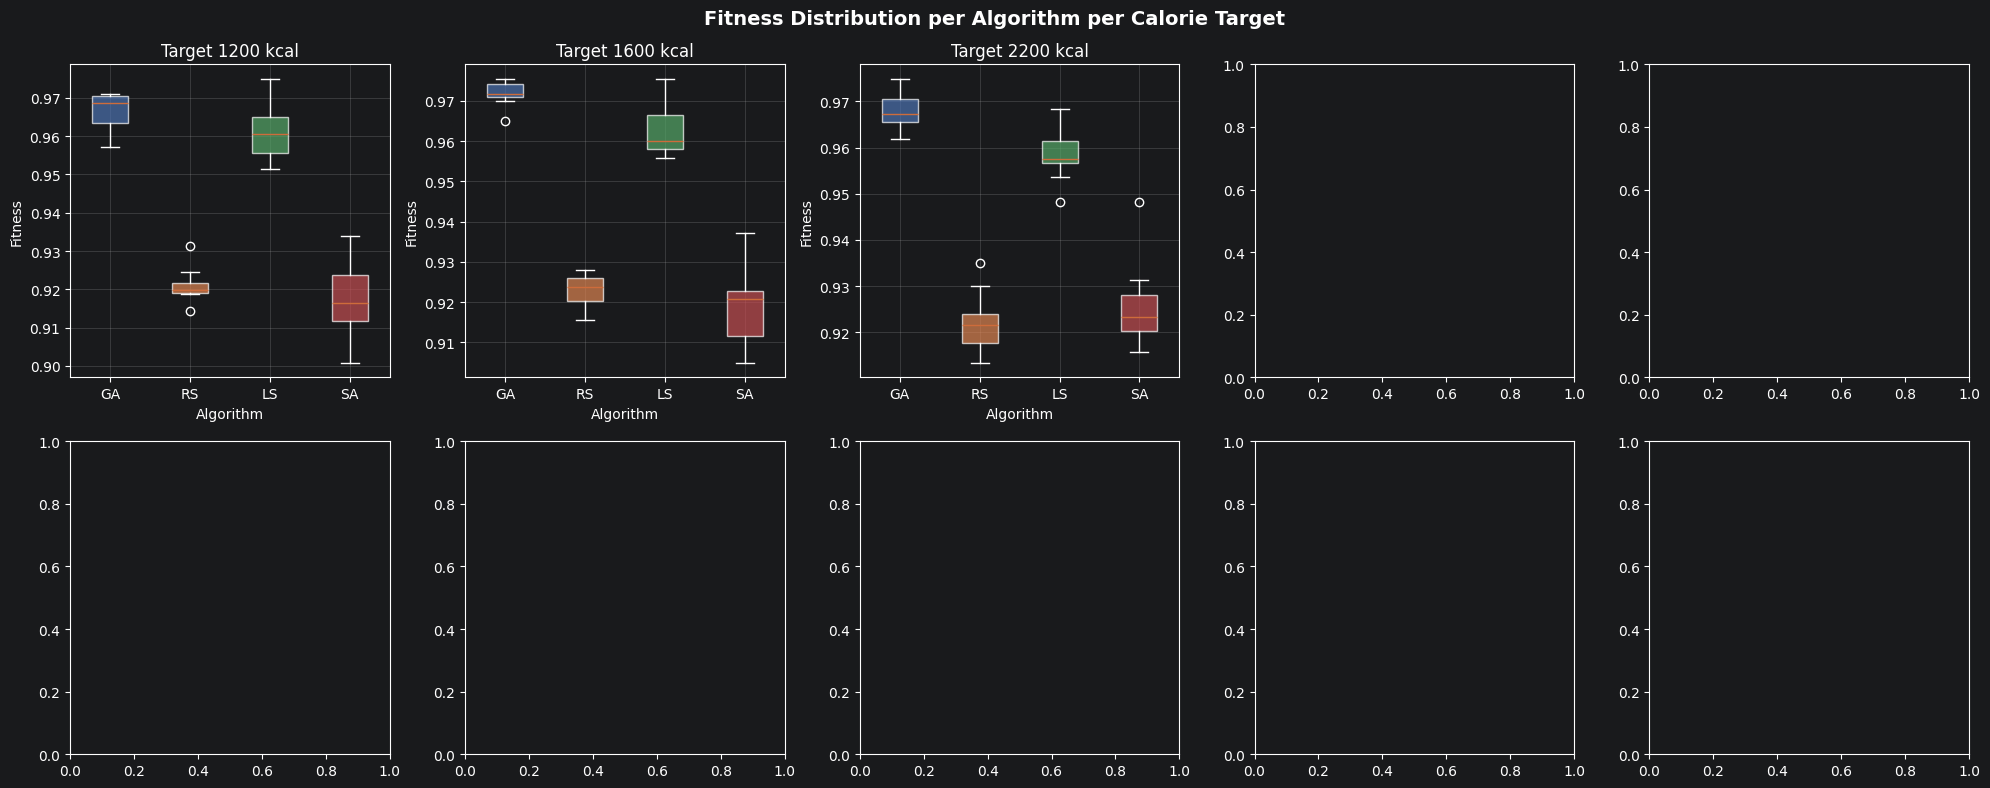

In [22]:
# Box plot
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, target in enumerate(target_cals):
    ga = all_ga_results[target]
    rs = all_results[target]['rs']
    ls = all_results[target]['ls']
    sa = all_results[target]['sa']

    data = [ga, rs, ls, sa]
    labels = ['GA', 'RS', 'LS', 'SA']

    bp = axes[i].boxplot(data, labels=labels, patch_artist=True)

    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[i].set_title(f'Target {target} kcal')
    axes[i].set_xlabel('Algorithm')
    axes[i].set_ylabel('Fitness')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Fitness Distribution per Algorithm per Calorie Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Convergence plotting

# unify curves onto a common time grid
def interpolate_curve(convergence, time_grid):
    """
    Forward-fill: at each point in time_grid, return the best
    fitness recorded up to and including that moment.
    """
    times  = np.array([c[0] for c in convergence])
    values = np.array([c[1] for c in convergence])
    result = np.empty(len(time_grid))

    for k, tq in enumerate(time_grid):
        mask      = times <= tq
        result[k] = values[mask].max() if mask.any() else values[0]

    return result

In [24]:
# Convergence main experiment loop
# GA best parameters (from existing notebook)
#target_cals = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
target_cals = [1200, 1600, 2200]

pop_size = 95
cxpb     = 0.55
mutpb    = 0.17
patience = 50
N_RUNS   = 10
N_POINTS = 300

best_curves  = {algo: {} for algo in ['GA', 'SA', 'LS', 'RS']}
time_budgets = {}

for target in target_cals:
    global TARGET_KCAL
    TARGET_KCAL = target

    print(f"\n{'='*60}")
    print(f"  TARGET {target} kcal")
    print(f"{'='*60}")

    # ── GA: 10 runs, pick best run ────────────────────────────────
    print("  [GA] running 10 times ...")
    ga_runs = []

    for run in range(N_RUNS):
        fit, curve = run_ga_with_convergence(target, pop_size, cxpb, mutpb, patience)
        runtime    = curve[-1][0]
        ga_runs.append((fit, runtime, curve))
        print(f"    run {run+1:>2}  fitness={fit:.6f}  time={runtime:.2f}s")

    # Best GA run = highest final fitness
    best_ga                                  = max(ga_runs, key=lambda x: x[0])
    best_ga_fitness, best_ga_runtime, best_ga_curve = best_ga

    # Time budget = runtime of the best GA run
    budget = best_ga_runtime
    time_budgets[target] = budget
    print(f"  Best GA fitness={best_ga_fitness:.6f}  ->  time budget={budget:.2f}s")

    tgrid = np.linspace(0, budget, N_POINTS)
    best_curves['GA'][target] = (tgrid, interpolate_curve(best_ga_curve, tgrid))

    # ── SA, LS, RS: 10 runs each, pick best run ───────────────────
    for algo_name, run_fn in [
        ('SA', lambda: run_sa_with_convergence(pop_size, budget)),
        ('LS', lambda: run_ls_with_convergence(pop_size, budget)),
        ('RS', lambda: run_rs_with_convergence(budget)),
    ]:
        print(f"  [{algo_name}] running 10 times ...")
        runs = []

        for run in range(N_RUNS):
            result = run_fn()
            if algo_name == 'RS':
                final_fitness, curve = result          # 2-tuple
            else:
                _, final_fitness, curve = result       # 3-tuple
            runs.append((final_fitness, curve))
            print(f"    run {run+1:>2}  fitness={final_fitness:.6f}")

        best_run     = max(runs, key=lambda x: x[0])
        best_fitness = best_run[0]
        best_curve   = best_run[1]
        print(f"  Best {algo_name} fitness={best_fitness:.6f}")
        best_curves[algo_name][target] = (tgrid, interpolate_curve(best_curve, tgrid))


  TARGET 1200 kcal
  [GA] running 10 times ...
    run  1  fitness=0.964486  time=3.59s
    run  2  fitness=0.972673  time=2.42s
    run  3  fitness=0.958432  time=1.78s
    run  4  fitness=0.954191  time=1.51s
    run  5  fitness=0.968117  time=4.14s
    run  6  fitness=0.967943  time=1.63s
    run  7  fitness=0.971426  time=4.74s
    run  8  fitness=0.965444  time=2.20s
    run  9  fitness=0.962189  time=1.94s
    run 10  fitness=0.968507  time=4.28s
  Best GA fitness=0.972673  ->  time budget=2.42s
  [SA] running 10 times ...
    run  1  fitness=0.917090
    run  2  fitness=0.935908
    run  3  fitness=0.940702
    run  4  fitness=0.914547
    run  5  fitness=0.933254
    run  6  fitness=0.925068
    run  7  fitness=0.925559
    run  8  fitness=0.927830
    run  9  fitness=0.908983
    run 10  fitness=0.923610
  Best SA fitness=0.940702
  [LS] running 10 times ...
    run  1  fitness=0.955769
    run  2  fitness=0.964383
    run  3  fitness=0.959956
    run  4  fitness=0.962255
   

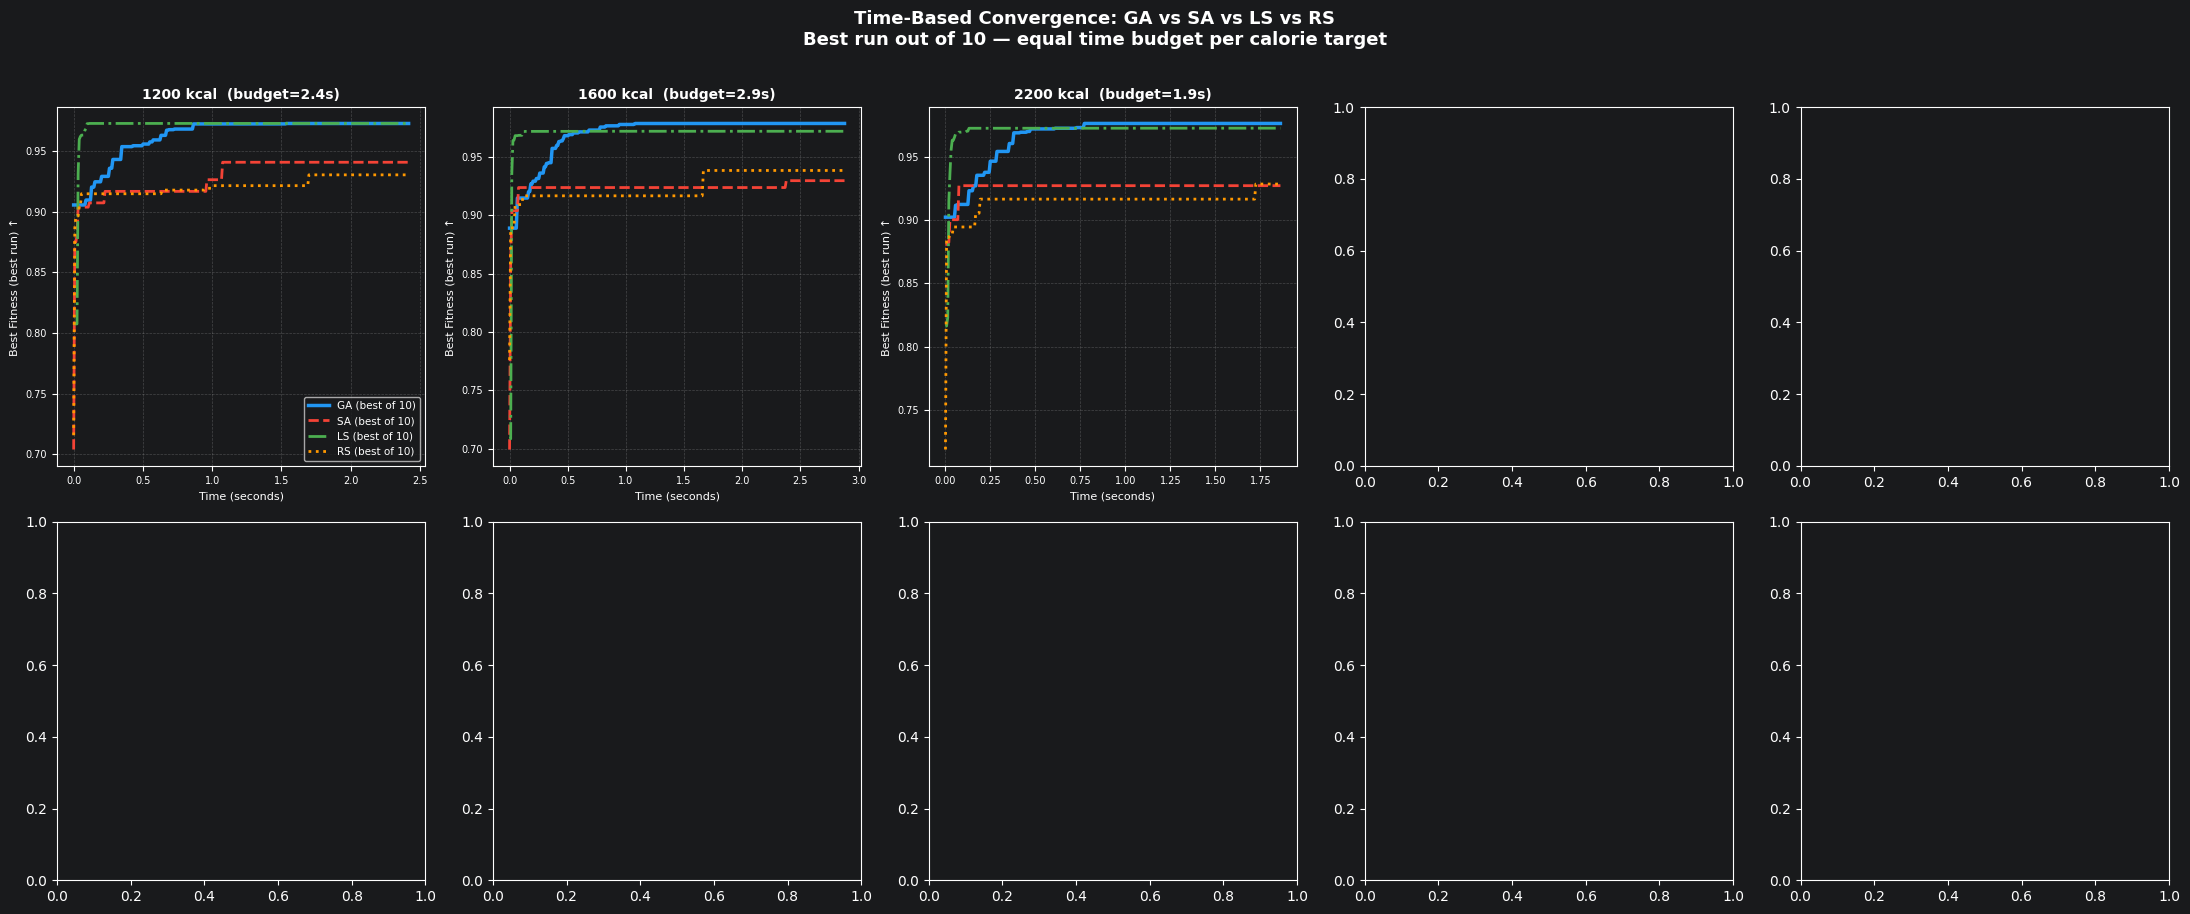

In [25]:
COLORS = {'GA': '#2196F3', 'SA': '#F44336', 'LS': '#4CAF50', 'RS': '#FF9800'}
STYLES = {'GA': '-',       'SA': '--',      'LS': '-.',      'RS': ':'}
WIDTHS = {'GA': 2.5,       'SA': 2.0,       'LS': 2.0,       'RS': 2.0}
LABELS = {
    'GA': 'GA (best of 10)',
    'SA': 'SA (best of 10)',
    'LS': 'LS (best of 10)',
    'RS': 'RS (best of 10)',
}

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for idx, target in enumerate(target_cals):
    ax = axes[idx]

    for algo in ['GA', 'SA', 'LS', 'RS']:
        tgrid, curve = best_curves[algo][target]
        ax.plot(tgrid, curve,
                color=COLORS[algo],
                linestyle=STYLES[algo],
                linewidth=WIDTHS[algo],
                label=LABELS[algo])

    ax.set_title(f'{target} kcal  (budget={time_budgets[target]:.1f}s)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Time (seconds)', fontsize=8)
    ax.set_ylabel('Best Fitness (best run) ↑', fontsize=8)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(labelsize=7)

    if idx == 0:
        ax.legend(fontsize=7.5, loc='lower right')

fig.suptitle(
    'Time-Based Convergence: GA vs SA vs LS vs RS\n'
    'Best run out of 10 — equal time budget per calorie target',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('convergence_plot_v4.png', dpi=200, bbox_inches='tight')
plt.show()